<a href="https://colab.research.google.com/github/amar4542/Future_DS_03/blob/main/Student%20Feedback.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [8]:
feedback = pd.read_csv("student_feedback.csv")
rating_cols = feedback.columns[2:]
feedback["Overall_Satisfaction"] = feedback[rating_cols].mean(axis=1)


survey = pd.read_csv("Student_Satisfaction_Survey.csv", encoding="latin1")
survey["Average_Score"] = survey["Average/ Percentage"].str.split("/").str[0].astype(float)


In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(feedback[rating_cols])

kmeans = KMeans(n_clusters=3, random_state=42)
feedback["Cluster"] = kmeans.fit_predict(X)

cluster_means = feedback.groupby("Cluster")[rating_cols].mean()
print(cluster_means)


         Well versed with the subject  \
Cluster                                 
0                            7.450000   
1                            6.855263   
2                            8.358804   

         Explains concepts in an understandable way  Use of presentations  \
Cluster                                                                     
0                                          6.056250              5.781250   
1                                          5.602632              5.781579   
2                                          6.714286              6.315615   

         Degree of difficulty of assignments  Solves doubts willingly  \
Cluster                                                                 
0                                   6.059375                 3.378125   
1                                   6.018421                 8.131579   
2                                   4.019934                 4.348837   

         Structuring of the course  \
Clus

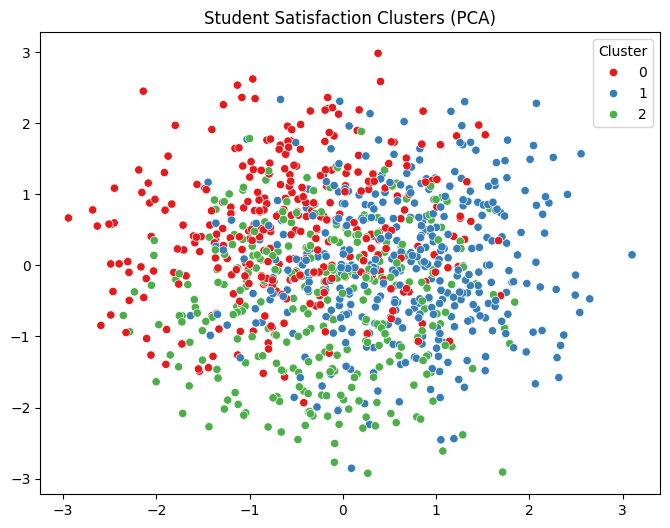

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=feedback["Cluster"], palette="Set1")
plt.title("Student Satisfaction Clusters (PCA)")
plt.show()


In [11]:
rating_cols = list(feedback.columns[2:])

In [12]:
corr = feedback[rating_cols + ["Overall_Satisfaction"]].corr()


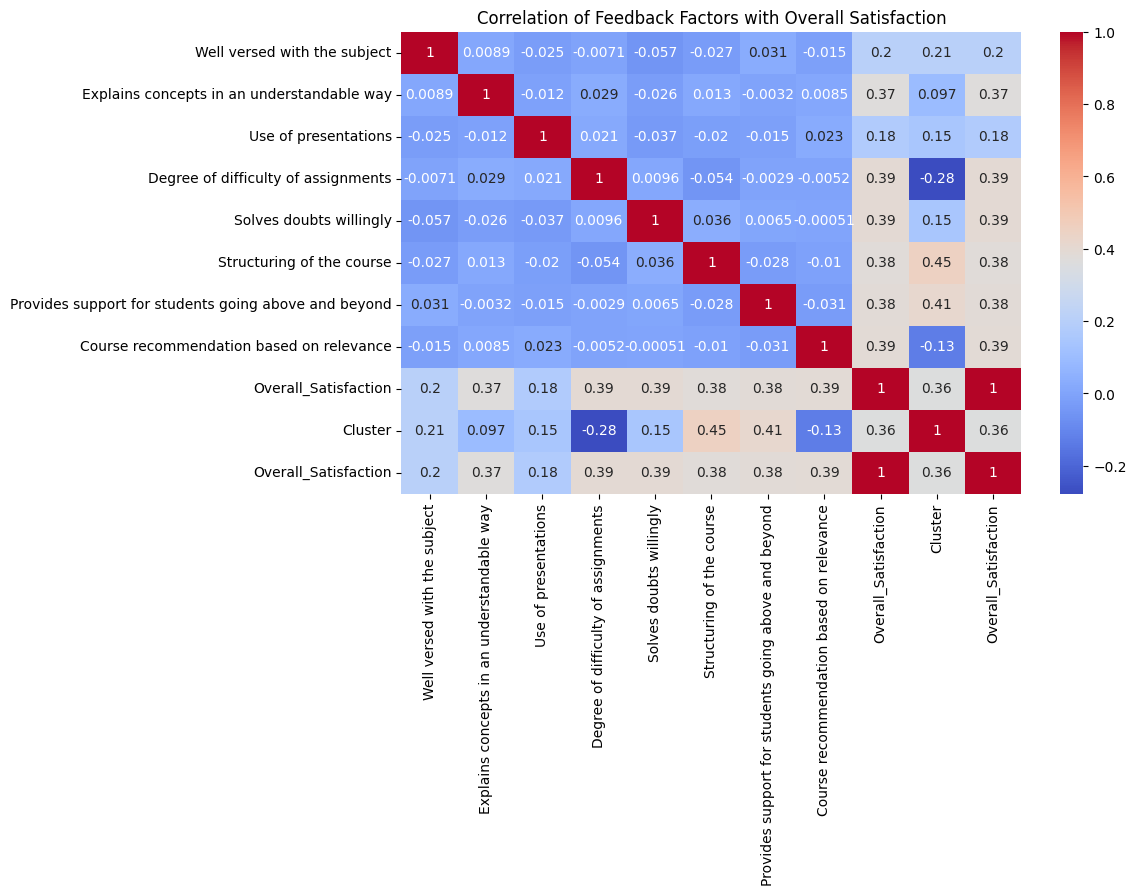

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation of Feedback Factors with Overall Satisfaction")
plt.show()


In [14]:
survey_ranking = survey.sort_values(by="Average_Score", ascending=False)[["Questions", "Average_Score"]]
print(survey_ranking)

                                             Questions  Average_Score
11   The teachers illustrate the concepts through e...           5.00
20   How much of the syllabus was covered in the cl...           5.00
1    How well did the teachers prepare for the clas...           5.00
229  Teachers inform you about your expected compet...           5.00
231  The teachers illustrate the concepts through e...           5.00
..                                                 ...            ...
17   Efforts are made by the institute/ teachers to...           2.00
550  Your mentor does a necessary follow-up with an...           2.00
211  The teachers illustrate the concepts through e...           1.67
212  The teachers identify your strengths and encou...           1.33
207  The teaching and mentoring process in your ins...           1.33

[580 rows x 2 columns]
